In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm.notebook import tqdm

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cpu


In [2]:
maxheight, maxwidth = 512, 512
batch_size = 32
n_epochs = 4

In [3]:
transform = transforms.Compose(
    [transforms.CenterCrop(np.maximum(maxheight, maxwidth)),
     transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# the data has to be at plankton-classifier/data/Training3_0 for the next line to work
dataset_all = datasets.ImageFolder('../data/Training3_0', transform=transform)
classnames = dataset_all.classes
print(f'found {len(dataset_all)} images, {len(classnames)} classes')

dataset = [d for d in dataset_all if d[0].shape[0] <= maxheight and d[0].shape[1] <= maxheight]
print(f'using {len(dataset)} images')

# create a train-test split with 90% training data and 10% testing data
train_split = int(len(dataset) * 0.9)
test_split = len(dataset) - train_split
train_dataset, test_dataset = random_split(dataset, [train_split, test_split])

train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)#, num_workers=2)
test_dataloader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)#, num_workers=2)

found 1855 images, 5 classes
using 1855 images


In [4]:
def showim(d):
    x,c = d
    plt.imshow(np.moveaxis(np.array(0.5 + x / 2.0), [0, 1, 2], [2, 0 , 1]))
    plt.title(f'{classnames[c]}')

In [5]:
classnames

['Copepods', 'EarlyStage', 'LongThin', 'MarineSnow', 'Radiolaria']

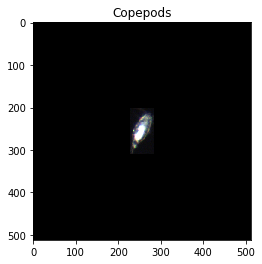

In [6]:
showim(dataset[5])

In [7]:
class Net(nn.Module):
    def __init__(self,
                 n_channels=None,
                 filter_sizes=None,
                 FC_n_hidden=None,
                 actfun=None,
                 n_classes=5):
        super(Net, self).__init__()
        
        if n_channels is None:
            n_channels = [3, 6, 16, 16, 16, 16, 16]
        if filter_sizes is None:
            filter_sizes = [5, 5, 5, 5, 5, 5]
        if FC_n_hidden is None:
            FC_n_hidden = [128, 64]
        self.actfun = F.relu if actfun is None else actfun
            
        assert len(n_channels) == len(filter_sizes) + 1
        
        self.filters = nn.ModuleList([nn.Conv2d(n_channels[j], n_channels[j + 1], filter_sizes[j])
                                      for j in range(len(filter_sizes))])
        self.pool = nn.MaxPool2d(2, 2)        
        n = (n_channels[-1], *FC_n_hidden, n_classes)
        self.FClayers = nn.ModuleList([nn.Linear(n[j], n[j+1])
                                       for j in range(len(n) - 1)])
        
    def forward(self, x, verbose=False):
        if verbose:
                print(x.shape)
        
        # convolutional filters
        for j in range(len(self.filters)):                        
            x = self.actfun(self.filters[j](x))
            if verbose:
                print(x.shape)
            x = self.pool(x)
            if verbose:
                print(x.shape)
        
        # sum over rows and column
        x = x.mean(axis=(2, 3))
        if verbose:
            print(x.shape)
            
        # fully connected layers
        for j in range(len(self.FClayers)):            
            x = self.FClayers[j](x)
            if j < len(self.FClayers) - 1:
                x = self.actfun(x)
            if verbose:
                print(x.shape)
        
        x = x.view(x.shape[0], -1)
        
        return x

In [8]:
net = Net()
net.to(device)

In [9]:
#check data flow through the network
d = dataset[0][0]
x = d.view((1, *d.shape))

y = net.forward(x, verbose=True)

torch.Size([1, 3, 512, 512])
torch.Size([1, 6, 508, 508])
torch.Size([1, 6, 254, 254])
torch.Size([1, 16, 250, 250])
torch.Size([1, 16, 125, 125])
torch.Size([1, 16, 121, 121])
torch.Size([1, 16, 60, 60])
torch.Size([1, 16, 56, 56])
torch.Size([1, 16, 28, 28])
torch.Size([1, 16, 24, 24])
torch.Size([1, 16, 12, 12])
torch.Size([1, 16, 8, 8])
torch.Size([1, 16, 4, 4])
torch.Size([1, 16])
torch.Size([1, 128])
torch.Size([1, 64])
torch.Size([1, 5])


In [10]:
criterion = nn.CrossEntropyLoss()
#optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
optimizer = optim.Adam(net.parameters(), lr=0.001)

for epoch in range(n_epochs):  # loop over the dataset multiple times

    print(f'epoch {epoch}')
    running_loss = 0.0
    for i, data in tqdm(enumerate(train_dataloader), total=len(train_dataloader)):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 10 == 9:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 10))
            running_loss = 0.0

print('Finished Training')

epoch 0


[1,    10] loss: 1.595
[1,    20] loss: 1.449
[1,    30] loss: 1.416
[1,    40] loss: 1.313
[1,    50] loss: 1.422

epoch 1


[2,    10] loss: 1.309
[2,    20] loss: 1.307
[2,    30] loss: 1.281
[2,    40] loss: 1.331
[2,    50] loss: 1.294

epoch 2


[3,    10] loss: 1.412
[3,    20] loss: 1.299
[3,    30] loss: 1.319
[3,    40] loss: 1.242
[3,    50] loss: 1.262

epoch 3


[4,    10] loss: 1.206
[4,    20] loss: 1.166
[4,    30] loss: 1.233
[4,    40] loss: 1.294
[4,    50] loss: 1.197

Finished Training


In [11]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
    for data in test_dataloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

In [15]:
print('Testing data')
for i in range(len(classnames)):
    print('Accuracy of %5s : %2d %%' % (
        classnames[i], 100 * class_correct[i] / class_total[i]))
print(f'Overall accuracy: {np.sum(class_correct) / np.sum(class_total)}')

Testing data
Accuracy of Copepods :  0 %
Accuracy of EarlyStage :  0 %
Accuracy of LongThin : 84 %
Accuracy of MarineSnow : 97 %
Accuracy of Radiolaria :  0 %
Overall accuracy: 0.5164769322947873


In [13]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
all_correct = 0

with torch.no_grad():
    for data in train_dataloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

In [16]:
print('Training data')

for i in range(len(classnames)):
    print('Accuracy of %5s : %2d %%' % (
        classnames[i], 100 * class_correct[i] / class_total[i]))
print(f'Overall accuracy: {np.sum(class_correct) / np.sum(class_total)}')

Training data
Accuracy of Copepods :  0 %
Accuracy of EarlyStage :  0 %
Accuracy of LongThin : 84 %
Accuracy of MarineSnow : 97 %
Accuracy of Radiolaria :  0 %
Overall accuracy: 0.5164769322947873
